In [1]:
import os
import zipfile
import splitfolders
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from PIL import Image
import seaborn as sns
import tensorflow as tf
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
from keras.preprocessing import image
from keras.models import load_model

In [2]:
local_zip = "C:/Users/My ASUS/Desktop/data/dataset.zip"
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall("C:/Users/My ASUS/Desktop/data")
zip_ref.close()

Jumlah kelas: 10
Kelas yang tersedia: ['Belimbing Wuluh', 'Jambu Biji', 'Jeruk Nipis', 'Kemangi', 'Lidah Buaya', 'Nangka', 'Pandan', 'Pepaya', 'Seledri', 'Sirih']


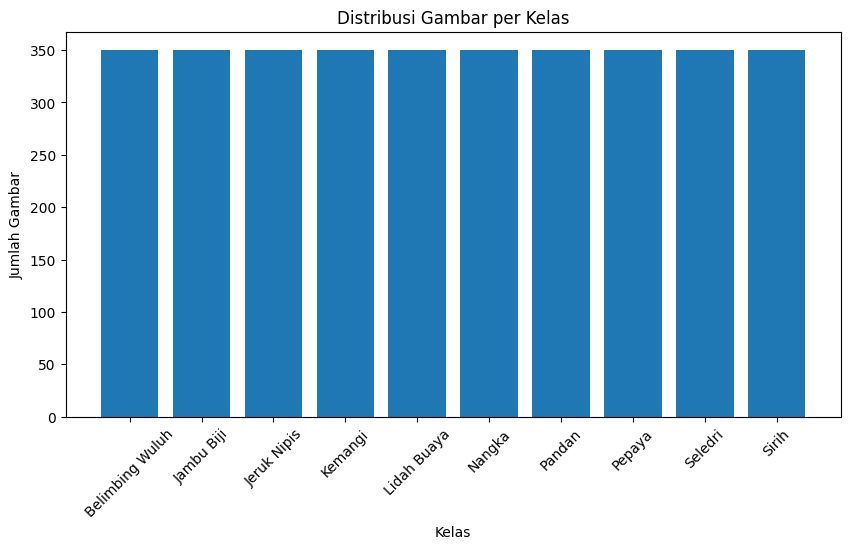

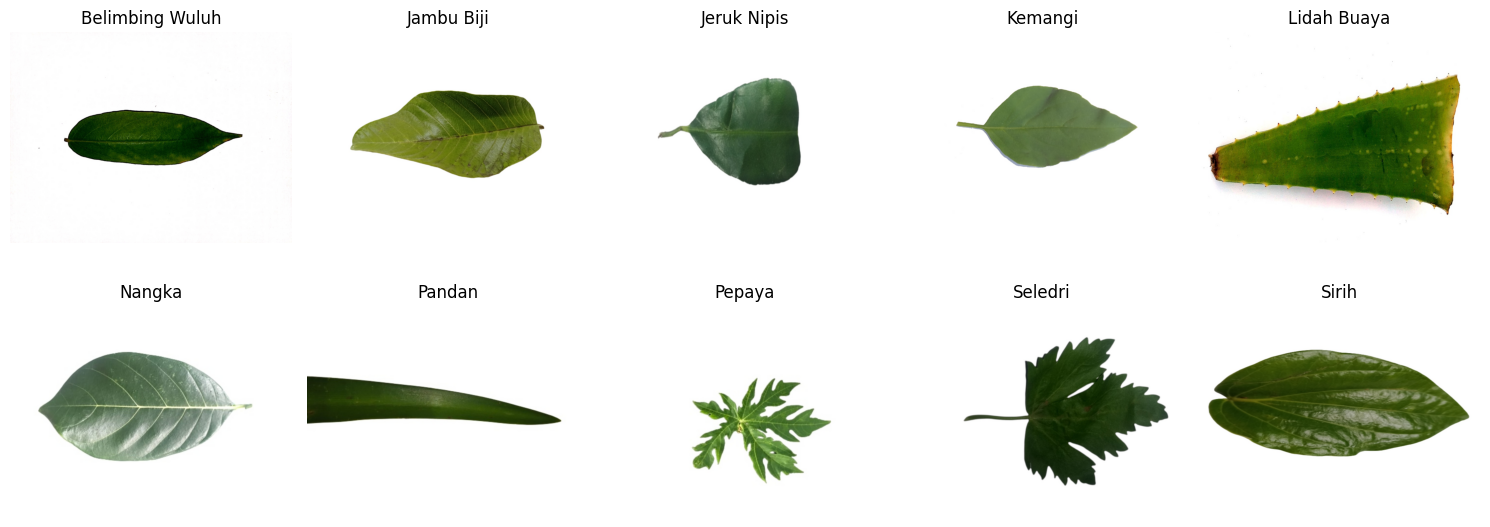

Ukuran gambar yang ditemukan: Counter({(1200, 1600): 10})


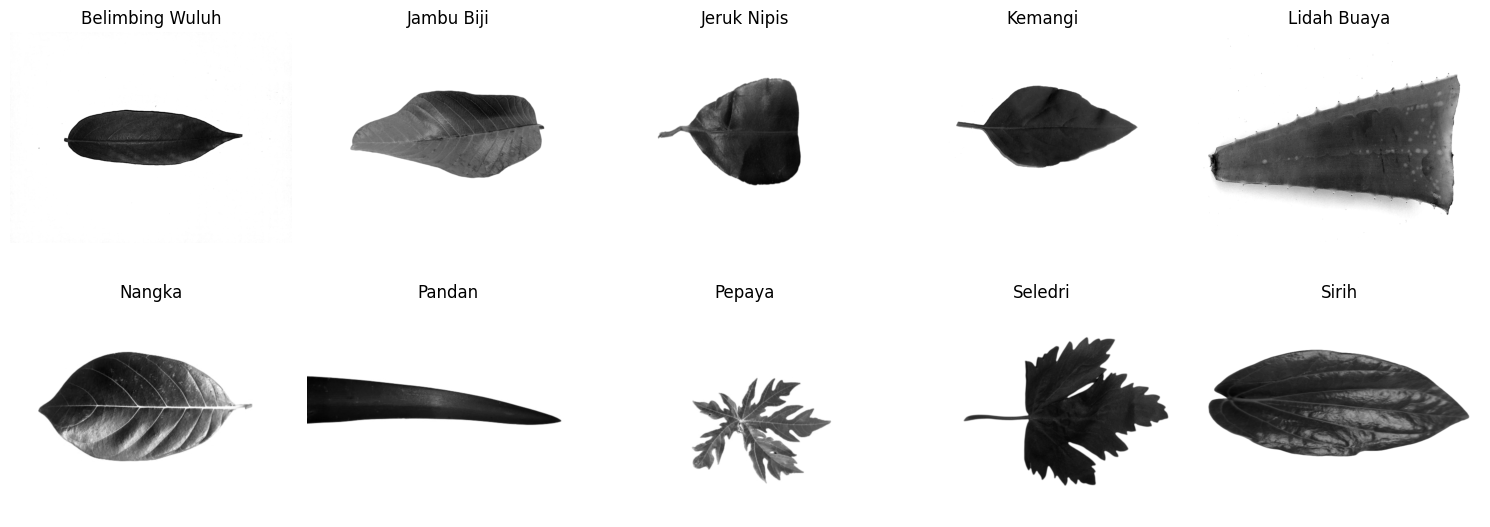

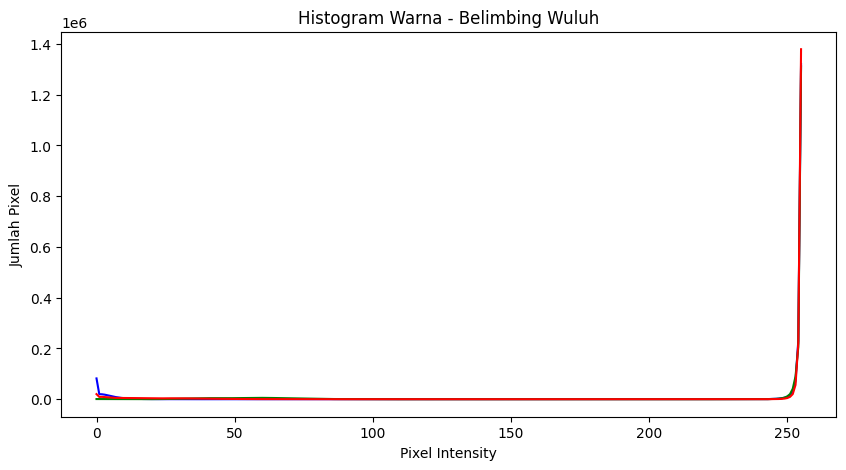

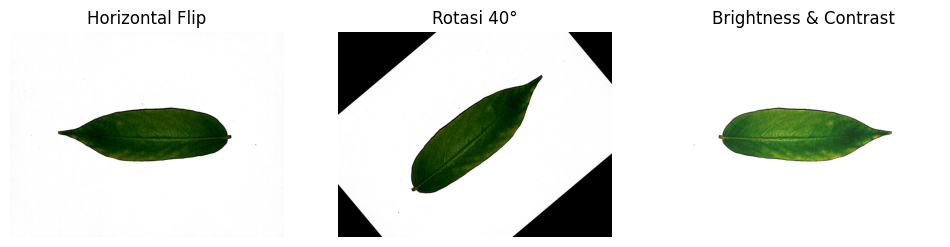

In [3]:
# Path dataset sebelum split
data_dir = "C:/Users/My ASUS/Desktop/data/dataset"
classes = os.listdir(data_dir)

# 1. Memahami Struktur Dataset
print(f"Jumlah kelas: {len(classes)}")
print(f"Kelas yang tersedia: {classes}")

# 2. Melihat Distribusi Data
image_counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}
plt.figure(figsize=(10, 5))
plt.bar(image_counts.keys(), image_counts.values())
plt.xticks(rotation=45)
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Gambar per Kelas")
plt.show()

# 3. Menampilkan Contoh Gambar
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
for ax, cls in zip(axes.flatten(), classes):
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()

# 4. Menganalisis Ukuran Gambar
image_sizes = []
for cls in classes:
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    img = cv2.imread(img_path)
    image_sizes.append(img.shape[:2])
size_counts = Counter(image_sizes)
print("Ukuran gambar yang ditemukan:", size_counts)

# 5. Mengecek Variasi dalam Gambar
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, cls in zip(axes.flatten(), classes):
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()

# 6. Menganalisis Warna dan Kontras
cls_sample = classes[0]
sample_img_path = os.path.join(data_dir, cls_sample, os.listdir(os.path.join(data_dir, cls_sample))[0])
sample_img = cv2.imread(sample_img_path)
colors = ("blue", "green", "red")
plt.figure(figsize=(10, 5))
for i, color in enumerate(colors):
    hist = cv2.calcHist([sample_img], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)
plt.title(f"Histogram Warna - {cls_sample}")
plt.xlabel("Pixel Intensity")
plt.ylabel("Jumlah Pixel")
plt.show()

# 7. Mengecek Augmentasi Data tanpa pustaka tambahan
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Membaca gambar
img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR ke RGB untuk matplotlib

# Augmentasi 1: Horizontal Flip
img_flip = cv2.flip(img, 1)

# Augmentasi 2: Rotasi 40 derajat
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 40, 1.0)
img_rotated = cv2.warpAffine(img, M, (w, h))

# Augmentasi 3: Brightness & Contrast Adjustment
alpha = 1.5  # Kontras (1.0 = normal)
beta = 30    # Kecerahan (0 = normal)
img_bright = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

# Menampilkan hasil augmentasi
images = [img_flip, img_rotated, img_bright]
titles = ["Horizontal Flip", "Rotasi 40°", "Brightness & Contrast"]

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i])
    ax.axis("off")

plt.show()


In [4]:
splitfolders.ratio("C:/Users/My ASUS/Desktop/data/dataset", 
                   output="C:/Users/My ASUS/Desktop/data/split_dataset", 
                   seed=1337, ratio=(.7, .2, .1), group_prefix=None)

In [5]:
base_dir = "C:/Users/My ASUS/Desktop/data/split_dataset"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')
classes = ["Sirih","Seledri","Pepaya","Pandan","Nangka","Lidah buaya","Kemangi","Jeruk Nipis","Jambu biji","Belimbing Wuluh"]

sirih_train_path = os.path.join(train_dir, 'Sirih')
seledri_train_path = os.path.join(train_dir, 'Seledri')
pepaya_train_path = os.path.join(train_dir, 'Pepaya')
pandan_train_path = os.path.join(train_dir, 'Pandan')
nangka_train_path = os.path.join(train_dir, 'Nangka')
lidahbuaya_train_path = os.path.join(train_dir, 'Lidah Buaya')
kemangi_train_path = os.path.join(train_dir, 'Kemangi')
jeruk_train_path = os.path.join(train_dir, 'Jeruk Nipis')
jambubiji_train_path = os.path.join(train_dir, 'Jambu Biji')
belimbingwuluh_train_path = os.path.join(train_dir, 'Belimbing Wuluh')

sirih_val_path = os.path.join(val_dir, 'Sirih')
seledri_val_path = os.path.join(val_dir, 'Seledri')
pepaya_val_path = os.path.join(val_dir, 'Pepaya')
pandan_val_path = os.path.join(val_dir, 'Pandan')
nangka_val_path = os.path.join(val_dir, 'Nangka')
lidahbuaya_val_path = os.path.join(val_dir, 'Lidah Buaya')
kemangi_val_path = os.path.join(val_dir, 'Kemangi')
jeruk_val_path = os.path.join(val_dir, 'Jeruk Nipis')
jambubiji_val_path = os.path.join(val_dir, 'Jambu Biji')
belimbingwuluh_val_path = os.path.join(val_dir, 'Belimbing Wuluh')

len_sirih_train = len(os.listdir(sirih_train_path))
len_seledri_train = len(os.listdir(seledri_train_path))
len_pepaya_train = len(os.listdir(pepaya_train_path))
len_pandan_train = len(os.listdir(pandan_train_path))
len_nangka_train = len(os.listdir(nangka_train_path))
len_lidahbuaya_train = len(os.listdir(lidahbuaya_train_path))
len_kemangi_train = len(os.listdir(kemangi_train_path))
len_jeruk_train = len(os.listdir(jeruk_train_path))
len_jambubiji_train = len(os.listdir(jambubiji_train_path))
len_belimbingwuluh_train = len(os.listdir(belimbingwuluh_train_path))

len_sirih_val = len(os.listdir(sirih_val_path))
len_seledri_val = len(os.listdir(seledri_val_path))
len_pepaya_val = len(os.listdir(pepaya_val_path))
len_pandan_val = len(os.listdir(pandan_val_path))
len_nangka_val = len(os.listdir(nangka_val_path))
len_lidahbuaya_val = len(os.listdir(lidahbuaya_val_path))
len_kemangi_val = len(os.listdir(kemangi_val_path))
len_jeruk_val = len(os.listdir(jeruk_val_path))
len_jambubiji_val = len(os.listdir(jambubiji_val_path))
len_belimbingwuluh_val = len(os.listdir(belimbingwuluh_val_path))

print("Panjang train:", str(len_sirih_train + len_seledri_train + len_pepaya_train + len_pandan_train + len_nangka_train + len_lidahbuaya_train + len_kemangi_train + len_jeruk_train + len_jambubiji_train + len_belimbingwuluh_train))
print("Panjang validation:", str(len_sirih_val + len_seledri_val + len_pepaya_val + len_pandan_val + len_nangka_val + len_lidahbuaya_val + len_kemangi_val + len_jeruk_val + len_jambubiji_val + len_belimbingwuluh_val))

print('''\n==== Jumlah data train ====
Panjang data train Sirih: {}
Panjang data train Peledri: {}
Panjang data train Pepaya: {}
Panjang data train Pandan: {}
Panjang data train Nangka: {}
Panjang data train Lidah Buaya: {}
Panjang data train Kemangi: {}
Panjang data train Jeruk Nipis: {}
Panjang data train Jambu Biji: {}
Panjang data train Belimbing Wuluh: {}
'''.format(len_sirih_train, len_seledri_train, len_pepaya_train, len_pandan_train, len_nangka_train, len_lidahbuaya_train, len_kemangi_train, len_jeruk_train, len_jambubiji_train, len_belimbingwuluh_train))

print('''\n==== Jumlah data validation ====
Panjang data validation Sirih: {}
Panjang data validation Peledri: {}
Panjang data validation Pepaya: {}
Panjang data validation Pandan: {}
Panjang data validation Nangka: {}
Panjang data validation Lidah Buaya: {}
Panjang data validation Kemangi: {}
Panjang data validation Jeruk Nipis: {}
Panjang data validation Jambu Biji: {}
Panjang data validation Belimbing Wuluh: {}
'''.format(len_sirih_val, len_seledri_val, len_pepaya_val, len_pandan_val, len_nangka_val, len_lidahbuaya_val, len_kemangi_val, len_jeruk_val, len_jambubiji_val, len_belimbingwuluh_val))

Panjang train: 2440
Panjang validation: 700

==== Jumlah data train ====
Panjang data train Sirih: 244
Panjang data train Peledri: 244
Panjang data train Pepaya: 244
Panjang data train Pandan: 244
Panjang data train Nangka: 244
Panjang data train Lidah Buaya: 244
Panjang data train Kemangi: 244
Panjang data train Jeruk Nipis: 244
Panjang data train Jambu Biji: 244
Panjang data train Belimbing Wuluh: 244


==== Jumlah data validation ====
Panjang data validation Sirih: 70
Panjang data validation Peledri: 70
Panjang data validation Pepaya: 70
Panjang data validation Pandan: 70
Panjang data validation Nangka: 70
Panjang data validation Lidah Buaya: 70
Panjang data validation Kemangi: 70
Panjang data validation Jeruk Nipis: 70
Panjang data validation Jambu Biji: 70
Panjang data validation Belimbing Wuluh: 70



In [6]:
train_sirih_fnames = os.listdir(sirih_train_path)
train_seledri_fnames = os.listdir(seledri_train_path)
train_pepaya_fnames = os.listdir(pepaya_train_path)
train_pandan_fnames = os.listdir(pandan_train_path)
train_nangka_fnames = os.listdir(nangka_train_path)
train_lidahbuaya_fnames = os.listdir(lidahbuaya_train_path)
train_kemangi_fnames = os.listdir(kemangi_train_path)
train_jeruk_fnames = os.listdir(jeruk_train_path)
train_jambubiji_fnames = os.listdir(jambubiji_train_path)
train_belimbingwuluh_fnames = os.listdir(belimbingwuluh_train_path)

print(train_sirih_fnames[:10])
print(train_seledri_fnames[:10])
print(train_pepaya_fnames[:10])
print(train_pandan_fnames[:10])
print(train_nangka_fnames[:10])
print(train_lidahbuaya_fnames[:10])
print(train_kemangi_fnames[:10])
print(train_jeruk_fnames[:10])
print(train_jambubiji_fnames[:10])
print(train_belimbingwuluh_fnames[:10])

['Sirih001.jpg', 'Sirih002.jpg', 'Sirih003.jpg', 'Sirih004.jpg', 'Sirih005.jpg', 'Sirih006.jpg', 'Sirih008.jpg', 'Sirih011.jpg', 'Sirih012.jpg', 'Sirih014.jpg']
['Seledri001.jpg', 'Seledri002.jpg', 'Seledri003.jpg', 'Seledri004.jpg', 'Seledri005.jpg', 'Seledri006.jpg', 'Seledri008.jpg', 'Seledri011.jpg', 'Seledri012.jpg', 'Seledri014.jpg']
['Pepaya001.jpg', 'Pepaya002.jpg', 'Pepaya003.jpg', 'Pepaya004.jpg', 'Pepaya005.jpg', 'Pepaya006.jpg', 'Pepaya008.jpg', 'Pepaya011.jpg', 'Pepaya012.jpg', 'Pepaya014.jpg']
['Pandan001.jpg', 'Pandan002.jpg', 'Pandan003.jpg', 'Pandan004.jpg', 'Pandan005.jpg', 'Pandan006.jpg', 'Pandan008.jpg', 'Pandan011.jpg', 'Pandan012.jpg', 'Pandan014.jpg']
['Nangka001.jpg', 'Nangka002.jpg', 'Nangka003.jpg', 'Nangka004.jpg', 'Nangka005.jpg', 'Nangka006.jpg', 'Nangka008.jpg', 'Nangka011.jpg', 'Nangka012.jpg', 'Nangka014.jpg']
['Lidah Buaya001.jpg', 'Lidah Buaya002.jpg', 'Lidah Buaya003.jpg', 'Lidah Buaya004.jpg', 'Lidah Buaya005.jpg', 'Lidah Buaya006.jpg', 'Lidah Buaya

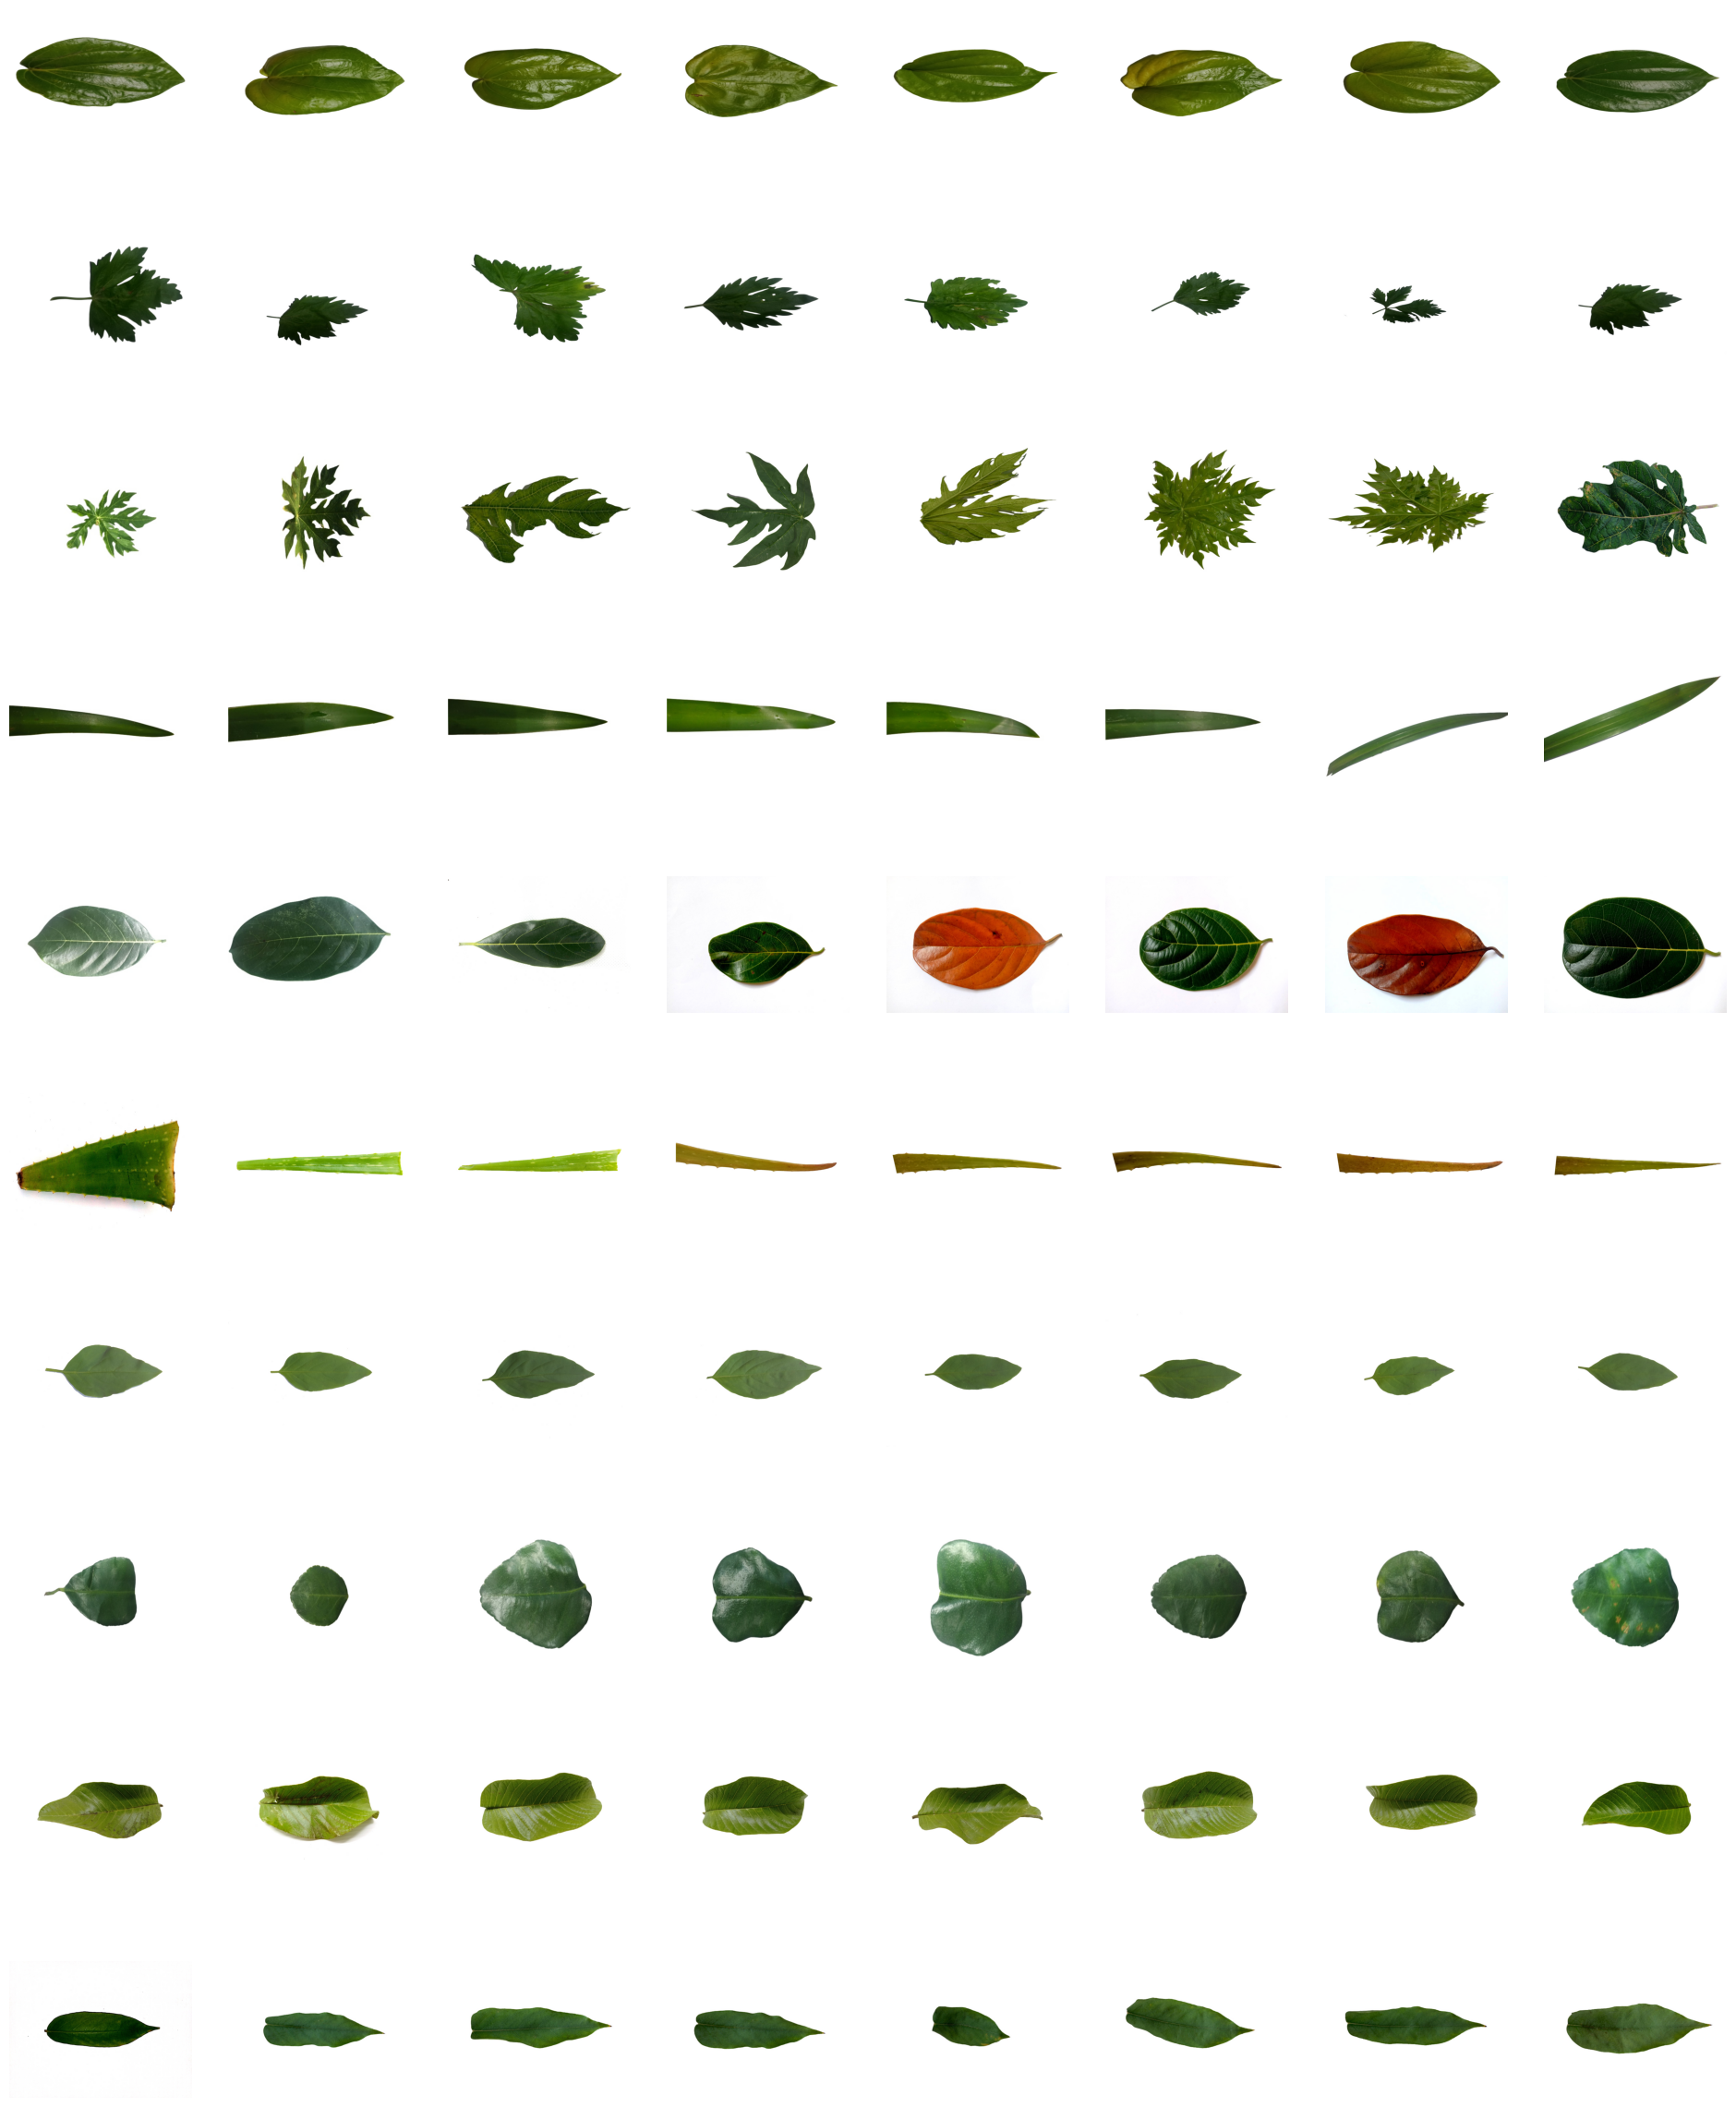

In [7]:
base_dir = "C:/Users/My ASUS/Desktop/data/split_dataset"
dirs = {"train": os.path.join(base_dir, 'train'), "val": os.path.join(base_dir, 'val')}
nrows, ncols = 10, 8  # 10 baris x 8 kolom
fig = plt.figure(figsize=(ncols * 3, nrows * 3))

image_paths = []
for cls in classes:
    train_path = os.path.join(dirs["train"], cls)
    image_paths.extend([os.path.join(train_path, fname) for fname in os.listdir(train_path)[:8] if fname.endswith(('.png', '.jpg', '.jpeg'))])

for i, img_path in enumerate(image_paths[:nrows * ncols]):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off')
    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

In [8]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.3,
    zoom_range = 0.3,
    rotation_range = 30,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
)
validation_datagen = ImageDataGenerator(
    rescale = 1./255,
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150,150),
    batch_size = 16,
    class_mode = 'categorical',
    shuffle=True,
)

validation_generator = validation_datagen.flow_from_directory(
    val_dir,
    target_size = (150,150),
    batch_size = 16,
    class_mode = 'categorical',
    shuffle = False,
)

test_datagen = ImageDataGenerator(
    rescale = 1./255,
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (150,150),
    batch_size = 16,
    class_mode = 'categorical',
    shuffle = False,
)

Found 2440 images belonging to 10 classes.
Found 700 images belonging to 10 classes.
Found 360 images belonging to 10 classes.


In [9]:
# Ukuran gambar
image_size = (150, 150, 3)

# Membuat model CNN dari awal
model = Sequential([
    # Layer Konvolusi 1
    Conv2D(32, (3,3), activation='relu', input_shape=image_size),
    MaxPooling2D(pool_size=(2,2)),

    # Layer Konvolusi 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Layer Konvolusi 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten untuk mengubah ke bentuk vektor
    Flatten(),

    # Fully Connected Layer
    Dense(512, activation='relu'),
    Dropout(0.5),  # Mengurangi overfitting
    Dense(10, activation='softmax')  # Output layer untuk 10 kelas
])

# Menampilkan arsitektur model
model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 17, 17, 128)      

In [10]:
model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs = {}):
    if(logs.get('accuracy') > 0.95):
      print('\nYour model accuration has been reached: 95%')
      self.model.stop_training = True

callbacks = myCallback()

history = model.fit(
    train_generator,
    epochs=60,
    validation_data=validation_generator,
    callbacks=[callbacks]
)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f'\nFinal Training Accuracy: {final_train_acc:.4f}')
print(f'Final Validation Accuracy: {final_val_acc:.4f}')



Epoch 1/60


153/153 [==============================] - 152s 968ms/step - loss: 1.8364 - accuracy: 0.3365 - val_loss: 1.3225 - val_accuracy: 0.4743
Epoch 2/60
153/153 [==============================] - 110s 717ms/step - loss: 1.3891 - accuracy: 0.4758 - val_loss: 1.1218 - val_accuracy: 0.5614
Epoch 3/60
153/153 [==============================] - 112s 731ms/step - loss: 1.2182 - accuracy: 0.5398 - val_loss: 1.3259 - val_accuracy: 0.5686
Epoch 4/60
153/153 [==============================] - 106s 692ms/step - loss: 1.1125 - accuracy: 0.5824 - val_loss: 1.0187 - val_accuracy: 0.6286
Epoch 5/60
153/153 [==============================] - 105s 683ms/step - loss: 1.0390 - accuracy: 0.6205 - val_loss: 0.7521 - val_accuracy: 0.7457
Epoch 6/60
153/153 [==============================] - 106s 692ms/step - loss: 0.8955 - accuracy: 0.6713 - val_loss: 0.5710 - val_accuracy: 0.7986
Epoch 7/60
153/153 [==============================] - 104s 677ms/step - loss: 0.8677 - accuracy: 0.6902 - val_loss: 0.668

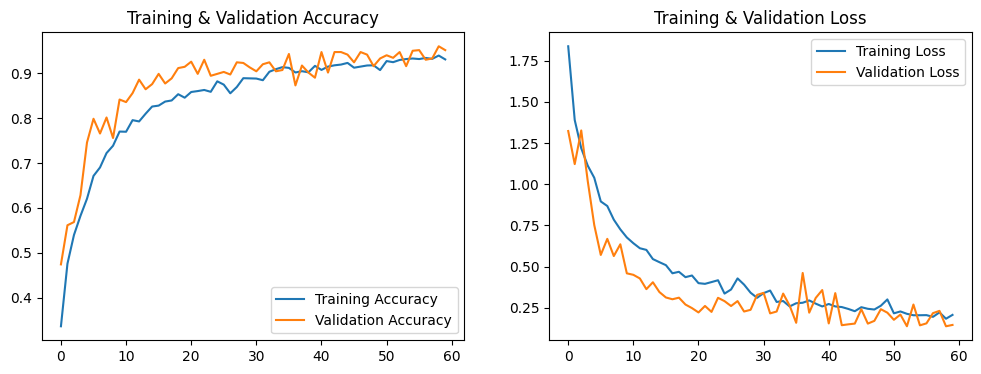

In [11]:
# Plot akurasi dan loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

In [12]:
# Prediksi pada data validasi
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes


# Laporan klasifikasi
class_report = classification_report(y_true, y_pred_classes, target_names=validation_generator.class_indices.keys())
print("Classification Report:\n", class_report)


44/44 [==============================] - 14s 322ms/step
Classification Report:
                  precision    recall  f1-score   support

Belimbing Wuluh       0.97      0.94      0.96        70
     Jambu Biji       0.92      0.97      0.94        70
    Jeruk Nipis       0.90      0.87      0.88        70
        Kemangi       0.92      0.94      0.93        70
    Lidah Buaya       0.90      1.00      0.95        70
         Nangka       1.00      1.00      1.00        70
         Pandan       1.00      0.89      0.94        70
         Pepaya       0.99      1.00      0.99        70
        Seledri       0.97      0.99      0.98        70
          Sirih       0.97      0.91      0.94        70

       accuracy                           0.95       700
      macro avg       0.95      0.95      0.95       700
   weighted avg       0.95      0.95      0.95       700



44/44 [==============================] - 14s 325ms/step


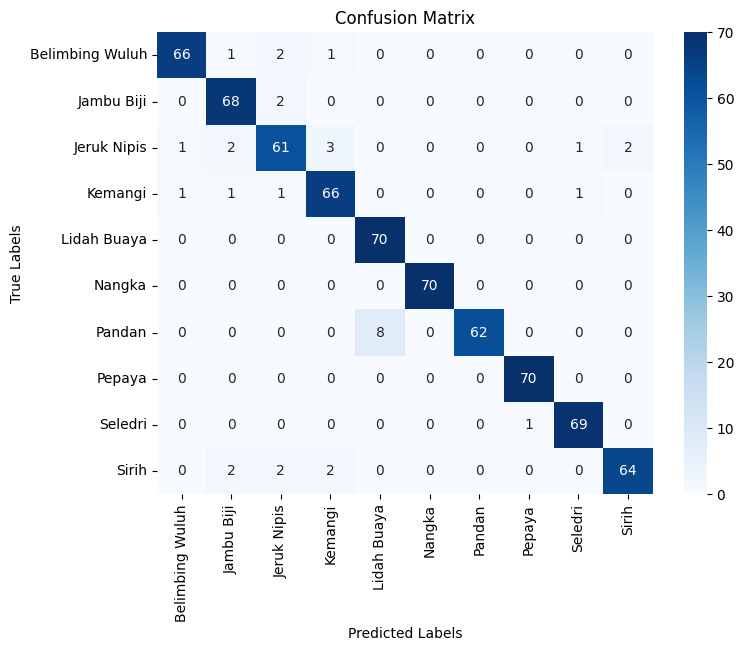

In [13]:
true_labels = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
conf_matrix = confusion_matrix(true_labels, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

1/1 [==============================] - 0s 207ms/step
Kemangi


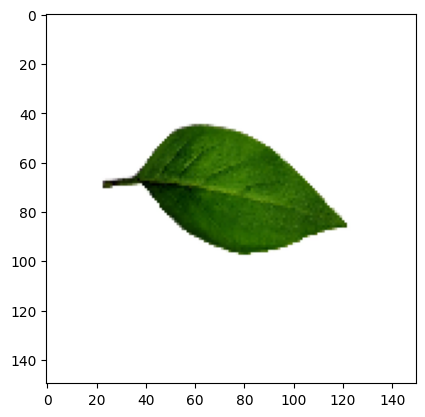

In [14]:
path_test = 'C:/Users/My ASUS/Desktop/data/split_dataset/test/Kemangi/Kemangi328.jpg'

img = image.load_img(path_test, target_size=(150,150))
imgplot = plt.imshow(img)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

images = np.vstack([x])
classes = model.predict(images, batch_size=10)

class_list = os.listdir(train_dir)

if classes[0][0]:
    prediction="Belimbing Wuluh"
elif classes[0][1]:
    prediction="Jambu Biji"
elif classes[0][2]:
    prediction="Jeruk"
elif classes[0][3]:
    prediction="Kemangi"
elif classes[0][4]:
    prediction="Lidah Buaya"
elif classes[0][5]:
    prediction="Nangka"
elif classes[0][6]:
    prediction="Pandan"
elif classes[0][7]:
    prediction="Pepaya"
elif classes[0][8]:
    prediction="Seledri"
elif classes[0][9]:
    prediction="Sirih"
else:
    prediction="[Undefined]"
print(prediction)

In [15]:
model.save('C:/Users/My ASUS/Desktop/data/model_cnn_daunherbal.h5')
model = load_model('C:/Users/My ASUS/Desktop/data/model_cnn_daunherbal.h5')

C:\Users\My ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
